# 01. Xử lý dữ liệu (Data Processing)

Làm sạch text, EDA cơ bản, và tạo các cột đặc trưng (feature) mà 3 bước
sau (ABSA, ad-hoc, Power BI export) đều cần dùng chung:
- **Lọc ngôn ngữ**: chỉ giữ lại review tiếng Việt 
- `review_text_clean`, `review_len`, `word_count`
- `dup_count`, `is_template_like` (review rác/mẫu có sẵn - trùng lặp hàng loạt)
- `aspect_<tên khía cạnh>` (cờ 0/1, review có nhắc khía cạnh đó không)

**Input:** `data/skincare_product.csv` (output của `00_data_collection_merge.ipynb`)

**Output:** `outputs/clean_reviews.csv`, `outputs/non_vietnamese_reviews.csv`,
`outputs/figures/*.png`, `outputs/eda_summary.txt`

In [ ]:
import sys
sys.path.append("../scripts")
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from common import clean_text, ASPECT_KEYWORDS, detect_aspects

DATA_PATH = "...\\data\\skincare_product.csv"
OUT_DIR = "...\\outputs"
FIG_DIR = f"{OUT_DIR}/figures"

df = pd.read_csv(DATA_PATH)

log_lines = []
def log(msg):
    print(msg)
    log_lines.append(str(msg))

log(f"Số dòng: {len(df)} | Số cột: {df.shape[1]}")
log(f"Số brand: {df['brand_name'].nunique()} -> {df['brand_name'].unique().tolist()}")
log(f"Số sản phẩm (product_id) duy nhất: {df['product_id'].nunique()}")
log(f"\nPhân bố review_score:\n{df['review_score'].value_counts().sort_index()}")

Số dòng: 7806 | Số cột: 10
Số brand: 5 -> ['Murad', 'Obagi', 'URIAGE', 'Eucerin', 'CeraVe']
Số sản phẩm (product_id) duy nhất: 153

Phân bố review_score:
review_score
1.0     260
2.0     108
3.0     231
4.0     374
5.0    6833
Name: count, dtype: int64


## 0. Lọc ngôn ngữ (chỉ giữ review tiếng Việt)

Bộ dữ liệu gốc (`data/skincare_product.csv`) chứa lẫn review tiếng Anh
và một số review bị `langdetect` nhận nhầm sang ngôn ngữ khác (thường là
review dạng gõ lung tung/spam khiến bộ nhận diện đoán sai). Vì lexicon
cảm xúc + khía cạnh ở notebook `02` chỉ được xây cho **tiếng Việt**, cần
lọc trước để tránh làm loãng mẫu số khi tính tỉ lệ % ở các bước sau.

In [6]:
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

def detect_language(text):
    # Review quá ngắn (vd "ok", "tốt") cho mặc định là tiếng Việt để xử lý tiếp,
    # vì langdetect không đủ tín hiệu để đoán đúng với chuỗi quá ngắn.
    if not isinstance(text, str) or len(text.strip()) < 5:
        return "vi"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

df["language"] = df["review_text"].apply(detect_language)
log("\n--- Phân bố ngôn ngữ trong dataset (top 10) ---")
log(df["language"].value_counts().head(10))

df_foreign = df[df["language"] != "vi"].copy()
df = df[df["language"] == "vi"].drop(columns=["language"]).reset_index(drop=True)

log(f"\nGiữ lại {len(df)} review tiếng Việt "
    f"(loại {len(df_foreign)} review không phải tiếng Việt, "
    f"~{len(df_foreign)/(len(df)+len(df_foreign))*100:.1f}% tổng dataset)")

df_foreign[["product_id", "brand_name", "review_score", "review_text", "language"]].to_csv(
    f"{OUT_DIR}/non_vietnamese_reviews.csv", index=False
)


--- Phân bố ngôn ngữ trong dataset (top 10) ---
language
vi    7425
en     197
so      20
fi      16
sk      14
sl      12
ru      12
hr      11
sq      10
cy       8
Name: count, dtype: int64

Giữ lại 7425 review tiếng Việt (loại 381 review không phải tiếng Việt, ~4.9% tổng dataset)


## 1. Làm sạch text

In [7]:
df["review_text_clean"] = df["review_text"].apply(clean_text)
df["review_len"] = df["review_text_clean"].str.len()
df["word_count"] = df["review_text_clean"].str.split().apply(len)

# bỏ review rỗng/gần rỗng trước khi tính các đặc trưng khác
df = df[df["review_len"] >= 3].reset_index(drop=True)
df["review_id"] = df.index
df.head()

,product_id,product_name,brand_name,price_current,price_original,sold_count,review_score,review_text,review_year,review_month,review_text_clean,review_len,word_count,review_id
0,2070262528,[Shock Deal 02.02 | 500K Off] Essence That Fad...,Murad,2372000,2445000.0,1800,2.0,Chất lượng:ko ok\nSản phẩm có dấu hiệu cạy mở....,2023.0,6.0,Chất lượng:ko ok Sản phẩm có dấu hiệu cạy mở. ...,568,140,0
1,2070262528,[Shock Deal 02.02 | 500K Off] Essence That Fad...,Murad,2372000,2445000.0,1800,5.0,"Giảm thâm nám nhanh chóng và hiệu quả, Giảm sự...",2026.0,4.0,"Giảm thâm nám nhanh chóng và hiệu quả, Giảm sự...",182,39,1
2,2070262528,[Shock Deal 02.02 | 500K Off] Essence That Fad...,Murad,2372000,2445000.0,1800,5.0,"Giảm thâm nám nhanh chóng và hiệu quả, Giảm sự...",2026.0,4.0,"Giảm thâm nám nhanh chóng và hiệu quả, Giảm sự...",124,29,2
3,2070262528,[Shock Deal 02.02 | 500K Off] Essence That Fad...,Murad,2372000,2445000.0,1800,5.0,"Thúc đẩy làn da mịn màng và rạng rỡ hơn, Huyết...",2026.0,3.0,"Thúc đẩy làn da mịn màng và rạng rỡ hơn, Huyết...",163,38,3
4,2070262528,[Shock Deal 02.02 | 500K Off] Essence That Fad...,Murad,2372000,2445000.0,1800,5.0,Tot,2026.0,3.0,Tot,3,1,4


## 2. Review trùng lặp / mẫu có sẵn (spam-like)

In [8]:
dup_counts = df["review_text_clean"].str.lower().value_counts()
df["dup_count"] = df["review_text_clean"].str.lower().map(dup_counts)
df["is_template_like"] = (df["review_len"] < 8) | (df["dup_count"] >= 5)
log(f"\nReview bị nghi là rác/mẫu có sẵn (quá ngắn hoặc lặp lại >=5 lần): "
    f"{df['is_template_like'].sum()} ({df['is_template_like'].mean()*100:.1f}%)")


Review bị nghi là rác/mẫu có sẵn (quá ngắn hoặc lặp lại >=5 lần): 133 (1.8%)


## 3. Cờ khía cạnh (multi-label) cho từng review

In [9]:
df["aspects"] = df["review_text_clean"].apply(detect_aspects)
for aspect in ASPECT_KEYWORDS:
    col = "aspect_" + aspect.split("/")[0].replace(" ", "_")
    df[col] = df["aspects"].apply(lambda lst: int(aspect in lst))
log(f"\nReview có ít nhất 1 khía cạnh nhận diện được: "
    f"{(df['aspects'].apply(len) > 0).sum()} ({(df['aspects'].apply(len) > 0).mean()*100:.1f}%)")


Review có ít nhất 1 khía cạnh nhận diện được: 5591 (75.9%)


## 4. Vài biểu đồ EDA

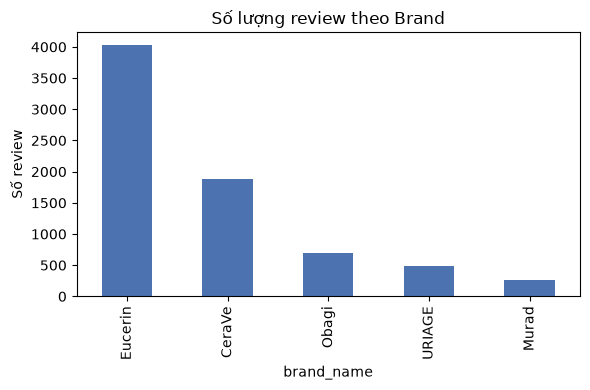

In [10]:
plt.figure(figsize=(6, 4))
df["brand_name"].value_counts().plot(kind="bar", color="#4C72B0")
plt.title("Số lượng review theo Brand")
plt.ylabel("Số review")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_reviews_per_brand.png", dpi=140)
plt.show()

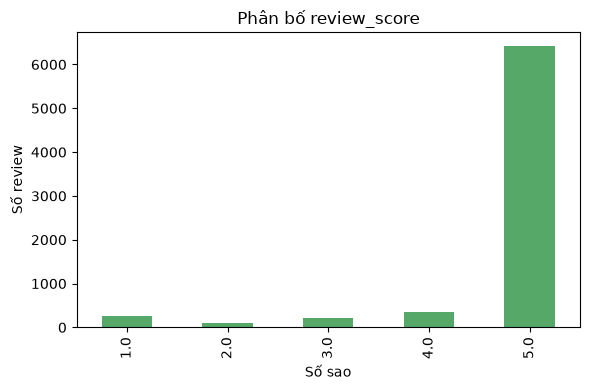

In [11]:
plt.figure(figsize=(6, 4))
df["review_score"].value_counts().sort_index().plot(kind="bar", color="#55a868")
plt.title("Phân bố review_score")
plt.xlabel("Số sao")
plt.ylabel("Số review")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_review_score_distribution.png", dpi=140)
plt.show()

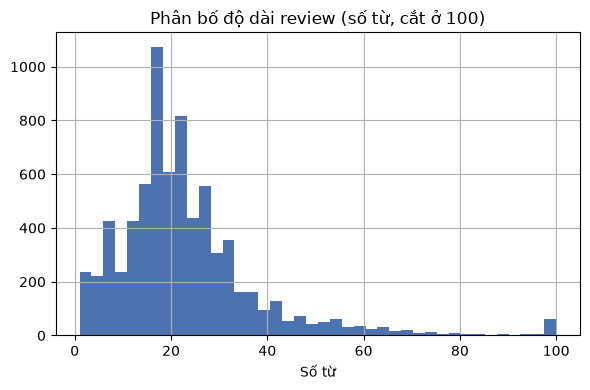

In [13]:
plt.figure(figsize=(6, 4))
df["word_count"].clip(upper=100).hist(bins=40, color="#4C72B0")
plt.title("Phân bố độ dài review (số từ, cắt ở 100)")
plt.xlabel("Số từ")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_review_length_hist.png", dpi=140)
plt.show()

## 5. Lưu dữ liệu đã xử lý

In [14]:
df.drop(columns=["aspects"]).to_csv(f"{OUT_DIR}/clean_reviews.csv", index=False)
with open(f"{OUT_DIR}/eda_summary.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(str(x) for x in log_lines))

log(f"\nĐã lưu {OUT_DIR}/clean_reviews.csv ({len(df)} dòng, {df.shape[1]-1} cột) "
    f"và biểu đồ trong {FIG_DIR}/")


Đã lưu E:\Final_project\skincare_project\outputs/clean_reviews.csv (7364 dòng, 23 cột) và biểu đồ trong E:\Final_project\skincare_project\outputs/figures/
